In [1]:
import pandas as pd
df=pd.read_csv('/home/sriaparna/AI/Churn Analysis/archive/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.info())
print(df.describe())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


/home/sriaparna/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/sriaparna/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.4' currently installed).
  from pandas.core import (


In [2]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
print(f"Missing TotalCharges: {df['TotalCharges'].isnull().sum()}")
df.dropna(inplace=True)

Missing TotalCharges: 11


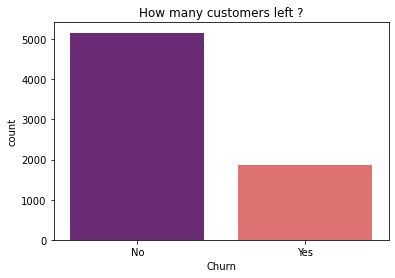

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [3]:
import matplotlib.pyplot as plt 
import seaborn as sns
plt.figure(figsize=(6,4))
sns.countplot(x='Churn',data=df,palette='magma')
plt.title('How many customers left ?')
plt.show()
print(df['Churn'].value_counts(normalize=True)*100)

In [4]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [5]:
print(df.corr(numeric_only=True)['Churn'].sort_values(ascending=False))

Churn             1.000000
MonthlyCharges    0.192858
SeniorCitizen     0.150541
TotalCharges     -0.199484
tenure           -0.354049
Name: Churn, dtype: float64


In [6]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col]=df[col].map({'Yes':1,'No':0})
df['gender']=df['gender'].map({'Female':1,'Male':0})


In [7]:
df = pd.get_dummies(df, columns=['Contract', 'PaymentMethod', 'InternetService', 
                                 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                                 'TechSupport', 'StreamingTV', 'StreamingMovies'])
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'PaperlessBilling',
       'MonthlyCharges', 'TotalCharges', 'Churn', 'Contract_Month-to-month',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovi

In [8]:
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)
df = pd.get_dummies(df)
print(df.corr()['Churn'].sort_values(ascending=False))

Churn                                      1.000000
Contract_Month-to-month                    0.404565
OnlineSecurity_No                          0.342235
TechSupport_No                             0.336877
InternetService_Fiber optic                0.307463
PaymentMethod_Electronic check             0.301455
OnlineBackup_No                            0.267595
DeviceProtection_No                        0.252056
MonthlyCharges                             0.192858
PaperlessBilling                           0.191454
SeniorCitizen                              0.150541
StreamingMovies_No                         0.130920
StreamingTV_No                             0.128435
StreamingTV_Yes                            0.063254
StreamingMovies_Yes                        0.060860
MultipleLines_Yes                          0.040033
PhoneService                               0.011691
gender                                     0.008545
MultipleLines_No phone service            -0.011691
MultipleLine

In [9]:
print(df.dtypes.value_counts())

bool       31
int64       8
float64     2
Name: count, dtype: int64


In [10]:
print(df.describe().round(2))

       gender  SeniorCitizen  Partner  Dependents   tenure  PhoneService  \
count  7032.0        7032.00  7032.00     7032.00  7032.00        7032.0   
mean      0.5           0.16     0.48        0.30    32.42           0.9   
std       0.5           0.37     0.50        0.46    24.55           0.3   
min       0.0           0.00     0.00        0.00     1.00           0.0   
25%       0.0           0.00     0.00        0.00     9.00           1.0   
50%       0.0           0.00     0.00        0.00    29.00           1.0   
75%       1.0           0.00     1.00        1.00    55.00           1.0   
max       1.0           1.00     1.00        1.00    72.00           1.0   

       PaperlessBilling  MonthlyCharges  TotalCharges    Churn  
count           7032.00         7032.00       7032.00  7032.00  
mean               0.59           64.80       2283.30     0.27  
std                0.49           30.09       2266.77     0.44  
min                0.00           18.25         18.80  

In [11]:
print(df.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'InternetService_DSL', 'InternetService_Fiber optic',
       'InternetService_No', 'OnlineSecurity_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No', 'OnlineBackup_No internet service',
       'OnlineBackup_Yes', 'DeviceProtection_No',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No', 'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'Strea

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

X=df.drop('Churn',axis=1)
Y=df['Churn']
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

model=RandomForestClassifier(n_estimators=100,class_weight='balanced',random_state=42)

model.fit(X_train,Y_train)
predictions=model.predict(X_test)

In [13]:
print(accuracy_score(Y_test, predictions))

0.7839374555792467


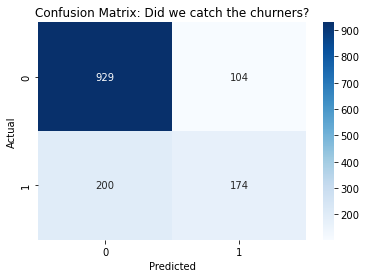

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
cm=confusion_matrix(Y_test,predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Did we catch the churners?')
plt.show()

In [15]:
print(df['Churn'].unique())

[0 1]


In [16]:
probabilities = model.predict_proba(X_test)
churn_risk = probabilities[:, 1]
print(churn_risk[:5])


[0.   0.12 0.57 0.11 0.22]


In [17]:
results = pd.DataFrame({
    'Actual_Churn': Y_test,
    'Churn_Probability': churn_risk
})
print(results.sort_values(by='Churn_Probability', ascending=False).head(10))

      Actual_Churn  Churn_Probability
6924             1               1.00
684              0               1.00
6933             1               1.00
2194             1               0.99
3346             0               0.99
1731             1               0.99
6488             1               0.99
1976             1               0.99
3771             1               0.99
6495             1               0.99


In [18]:
print(results.groupby('Actual_Churn')['Churn_Probability'].mean())

Actual_Churn
0    0.190134
1    0.485496
Name: Churn_Probability, dtype: float64


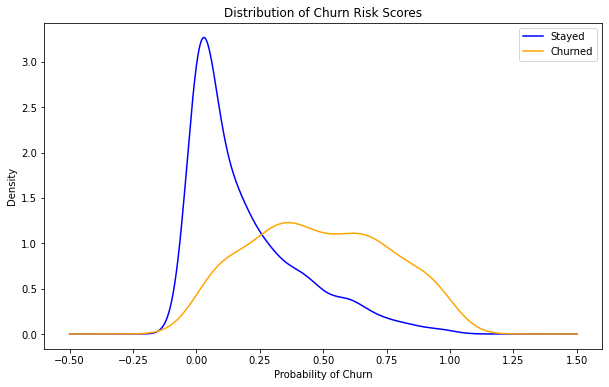

In [19]:
plt.figure(figsize=(10,6))
results[results['Actual_Churn'] == 0]['Churn_Probability'].plot(
    kind='density', label='Stayed', color='blue'
)
results[results['Actual_Churn'] == 1]['Churn_Probability'].plot(
    kind='density', label='Churned', color='orange'
)
plt.title('Distribution of Churn Risk Scores')
plt.xlabel('Probability of Churn')
plt.ylabel('Density')
plt.legend()
plt.show()

In [24]:
import sklearn
from sklearn.ensemble import RandomForestClassifier # or whichever model you use
import joblib

# After training:
joblib.dump(model, 'churn_rf_model.joblib')

['churn_rf_model.joblib']

In [21]:
pip install --upgrade scikit-learn joblib


[notice] A new release of pip is available: 23.3.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
